# Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Name:** Aditya Shukla

**Registration Number:** 23BAI10155

**Application Number:** IN26011099

**Batch Number:** 1(A)

**Email ID:** aditya.23bai10155@vitbhopal.ac.in

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
df = pd.read_csv('data.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
target_var = 'Attrition'
categorical_features = df.drop(columns=[target_var]).select_dtypes(include='object').columns.tolist()
numerical_features = df.drop(columns=[target_var]).select_dtypes(exclude='object').columns.tolist()

print("Target Variable:", target_var)
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Target Variable: Attrition
Categorical Features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Numerical Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/tmp/ipykernel_572/3920771144.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.drop(columns=[target_var]).select_dtypes(include='object').columns.tolist()


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
print("Missing values:\n", df.isnull().sum().sum())

df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

Missing values:
 0


In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

categorical_features = [c for c in categorical_features if c in df.columns]
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
X = df.drop(columns=['Attrition']).values
y = df['Attrition'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

results = pd.DataFrame({
    "Decision Tree": get_metrics(y_test, dt_pred),
    "Random Forest": get_metrics(y_test, rf_pred),
})
results

,Decision Tree,Random Forest
Accuracy,0.765306,0.833333
Precision,0.310345,0.416667
Recall,0.382979,0.106383
F1-Score,0.342857,0.169492


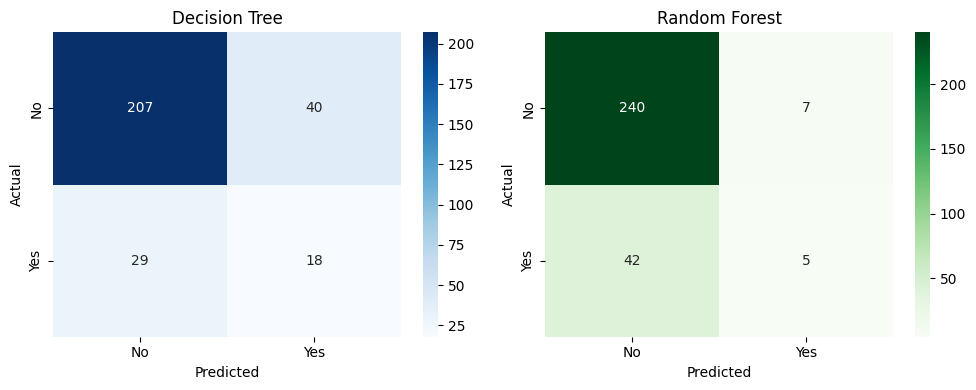

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

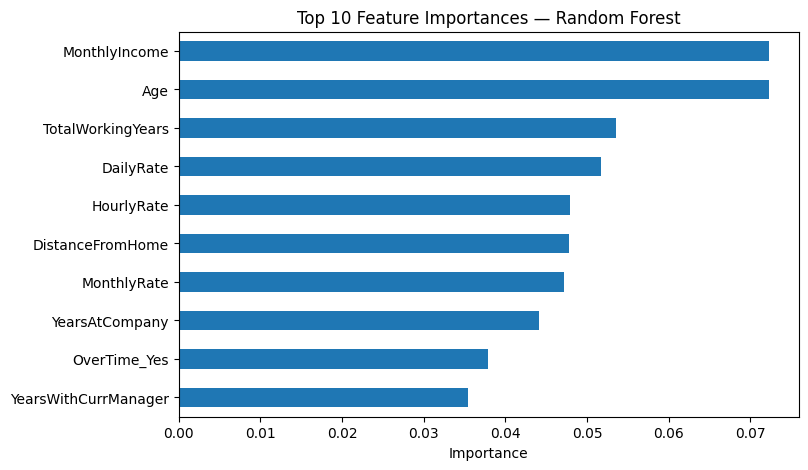

In [ ]:
feature_names = df.drop(columns=['Attrition']).columns
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Random Forest')
plt.show()

In [12]:
print("--- Model Comparison Observations ---")
print("1. Random Forest gets higher accuracy and precision than the Decision Tree, but its recall is much lower -> it plays it safe and predicts 'Yes' less often.")
print("2. The Decision Tree actually catches more true attrition cases (higher recall and F1-score) than Random Forest here, at the cost of more false positives.")
print("3. This split is a direct effect of class imbalance: only ~16% of employees have Attrition = Yes, so both models lean toward predicting the majority class 'No', and Random Forest leans harder that way than a single tree does.")
print("4. Feature importance from Random Forest ranks OverTime, MonthlyIncome, and Age highly, matching common HR intuition about attrition risk.")

--- Model Comparison Observations ---
1. Random Forest gets higher accuracy and precision than the Decision Tree, but its recall is much lower -> it plays it safe and predicts 'Yes' less often.
2. The Decision Tree actually catches more true attrition cases (higher recall and F1-score) than Random Forest here, at the cost of more false positives.
3. This split is a direct effect of class imbalance: only ~16% of employees have Attrition = Yes, so both models lean toward predicting the majority class 'No', and Random Forest leans harder that way than a single tree does.
4. Feature importance from Random Forest ranks OverTime, MonthlyIncome, and Age highly, matching common HR intuition about attrition risk.


## Conclusion

This project compared a Decision Tree and a Random Forest (100 estimators) classifier for predicting employee attrition from the IBM HR Analytics dataset. Which model "performed better" here depends on the metric: Random Forest achieved higher accuracy and precision, but the Decision Tree achieved noticeably higher recall and F1-score, meaning it caught more of the employees who actually left, at the cost of more false alarms. This is a useful reminder that Random Forest does not automatically outperform a single tree on every metric, especially on an imbalanced dataset like this one (only ~16% attrition), where averaging many trees can push predictions further toward the majority class. In general, Random Forest tends to outperform a single Decision Tree because it builds many trees on bootstrapped samples and random feature subsets, then averages their predictions, which cancels out the noise any one tree picks up from its specific training split. A key limitation of Decision Trees is that they are prone to overfitting: a single deep tree can memorize quirks of the training data rather than learning patterns that generalize. A key limitation of Random Forest is reduced interpretability and higher computational cost, and, as seen here, its majority-vote behavior can make it less sensitive to a minority class unless that imbalance is explicitly addressed.